In [3]:
"The notebook is for calculating the frustration score of gene regulation networks in each single cell. The gene regulation network is first inferenced with PLSR and locfdr. The single cell RNA vector is binarized  to calculate the frustration."


'The notebook is for calculate the frustration score of gene regulation networks in each single cell. The gene regulation network is first inferenced with PLSR and locfdr. The single cell RNA vector is binarized  to calculate the frustration.'

In [1]:
import dynamo as dyn
import numpy as np
from scipy import stats,signal
from matplotlib import pyplot as plt
from scipy import sparse
from sklearn.neighbors import KernelDensity
import networkx as nx
import os
import glob
import anndata
from scipy.interpolate import CubicSpline,interp1d
from voronoi_finite_polygons_2d import voronoi_finite_polygons_2d
from scipy.spatial import Voronoi, voronoi_plot_2d
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn import linear_model
from sklearn.feature_selection import VarianceThreshold
from scipy.sparse import csr_matrix

In [2]:
dim_n=10
result_path='result/'
adata=dyn.read(result_path+'EG_dyn.h5ad')
path=np.load(result_path+'EG_dyn_rc.npy')
rc_extend=np.load(result_path+'EG_rc_extend.npy')
gene_arr=np.load(result_path+'EG_bin_genes.npy',allow_pickle=True)

/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [3]:
V0_ori=adata.layers['velocity_S'].A
X0_ori=adata.layers['M_s'].A

In [4]:
from sklearn.impute import SimpleImputer,KNNImputer
imputer = KNNImputer(n_neighbors=5)
X0_ori=imputer.fit_transform(X0_ori)
imputer = KNNImputer(n_neighbors=5)
V0_ori=imputer.fit_transform(V0_ori)

In [5]:
X0=StandardScaler().fit_transform(X0_ori)
V0=StandardScaler().fit_transform(V0_ori)
print(X0.shape,V0.shape)
gene_list=adata.var.index.values

(3696, 737) (3696, 737)


In [6]:
"gene binarization besed on the clustering in 1st step"

'gene binarization besed on the clustering in 1st step'

In [7]:
bin_centers=np.load(result_path+'EG_bin_genes_center.npy',allow_pickle=True)
# print(bin_centers)
X0_bin=X0_ori.copy()
for i in range(X0_ori.shape[1]):
    gene_kc=bin_centers[i,:]
    x=X0_ori[:,i]
    x_dist0=abs(x-gene_kc[0])
    x_dist1=abs(x-gene_kc[1])
    
    X0_bin[:,i][x_dist0<x_dist1]=0
    X0_bin[:,i][x_dist0>=x_dist1]=1

In [8]:
"assigning reaction coordinate of each single cell"

'assigning reaction coordinate of each single cell'

In [9]:
data_rc=np.array([np.argmin(np.linalg.norm((adata.obsm['X_pca'][i,:dim_n]-rc_extend),axis=1)) for i in range(adata.shape[0])])
np.unique(data_rc,return_counts=True)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16]),
 array([ 449,  102,  156,  119,   90,   73,  267,   66,  121,   85,  139,
         226,   37,   43,   34,   47, 1642]))

In [10]:
path_neigh=[[] for i in range(rc_extend.shape[0])]
for i in range(rc_extend.shape[0]):
#     mask=np.in1d(np.argsort(np.linalg.norm((adata.obsm['X_pca'][:,:dim_n]-path[i,:]),axis=1))[:200],np.where(data_rc==i)[0])
#     path_neigh[i]=np.argsort(np.linalg.norm((adata.obsm['X_pca'][:,:dim_n]-path[i,:]),axis=1))[:200][mask][:100].tolist()
#     print(len(path_neigh[i]))
    mask=np.in1d(np.where(data_rc==i)[0],np.argsort(np.linalg.norm((adata.obsm['X_pca'][:,:dim_n]-rc_extend[i,:]),axis=1))[:200])
    path_neigh[i]=np.where(data_rc==i)[0][mask].tolist()
    print(len(path_neigh[i]))

107
87
121
107
90
71
108
31
37
74
91
158
33
41
34
45
55


/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:182: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


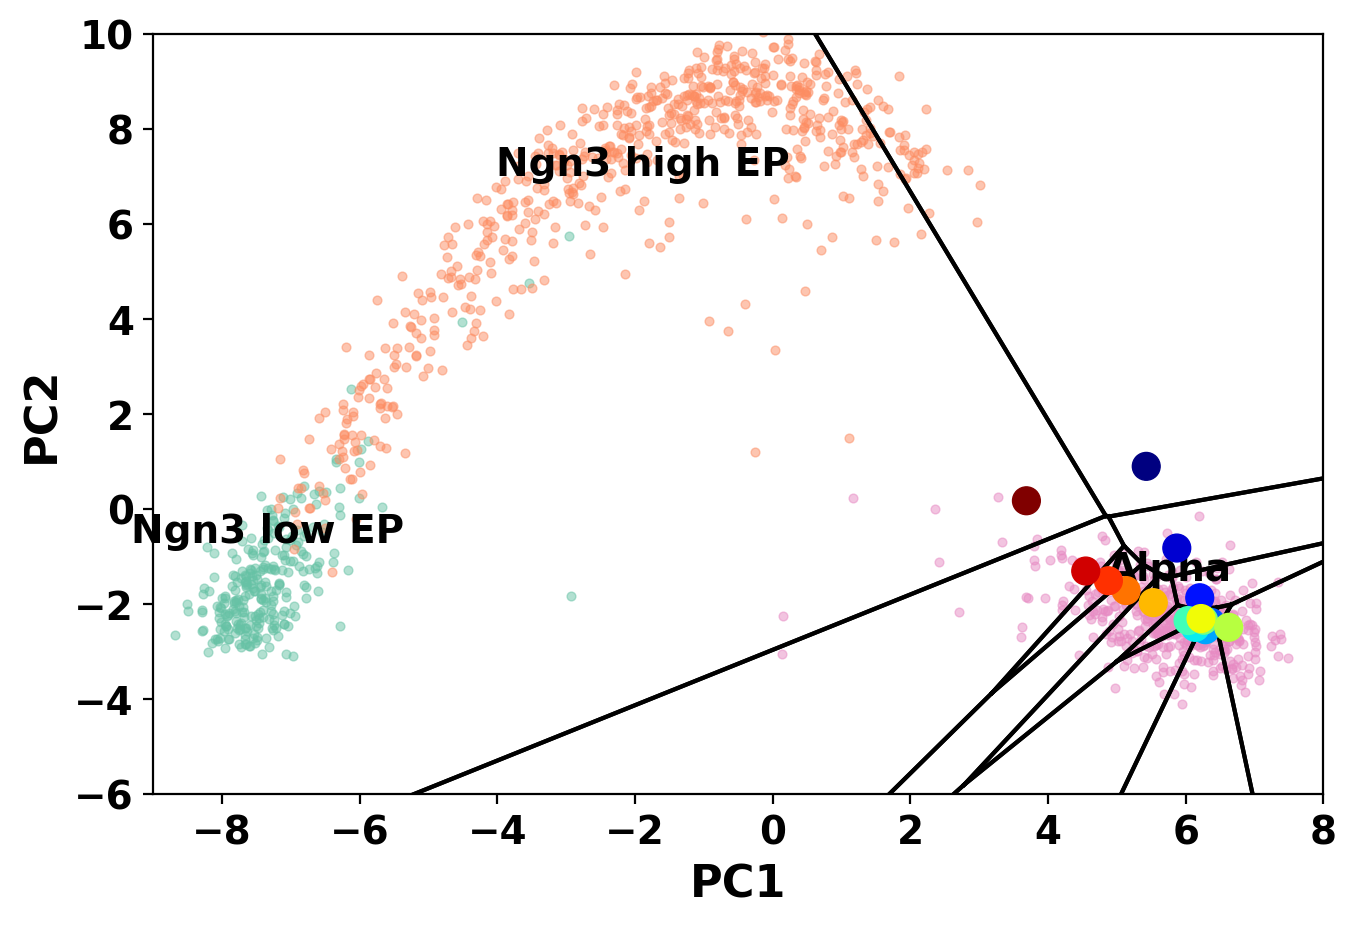

In [11]:
path_r=path.copy()
path_r[:,0]=-path[:,0]

t_list=['Ngn3 low EP', 'Ngn3 high EP', 'Fev+', 'Alpha']
fig,ax=plt.subplots(figsize=(7.5,5))
# ax.set_facecolor('silver')
colors =plt.cm.Set2([0,1,2,3])#plt.cm.Set2(np.linspace(0, 1, len(t_list)))
for ti in range(len(t_list)):                                      
    adata_t=adata[adata.obs['clusters']==t_list[ti],:]
    plt.scatter(-adata_t.obsm['X_pca'][:,0],adata_t.obsm['X_pca'][:,1],color=colors[ti],s=10,alpha=0.5)
    if ti==0: 
        plt.text(np.mean(-adata_t.obsm['X_pca'][:,0]),\
                 np.mean(adata_t.obsm['X_pca'][:,1])+1,\
                 t_list[ti],horizontalalignment='center',verticalalignment='center',\
                 fontweight='bold',fontsize=14,alpha=1,zorder=10)
        
    if ti==1: 
        plt.text(np.mean(-adata_t.obsm['X_pca'][:,0]),\
                 np.mean(adata_t.obsm['X_pca'][:,1])+0.5,\
                 t_list[ti],horizontalalignment='center',verticalalignment='center',\
                 fontweight='bold',fontsize=14,alpha=1,zorder=10)
        
    if ti==2: 
        plt.text(np.mean(-adata_t.obsm['X_pca'][:,0]),\
                 np.mean(adata_t.obsm['X_pca'][:,1])+0.5,\
                 t_list[ti],horizontalalignment='center',verticalalignment='center',\
                 fontweight='bold',fontsize=14,alpha=1,zorder=10)

    if ti==3: 
        plt.text(np.mean(-adata_t.obsm['X_pca'][:,0]),\
                 np.mean(adata_t.obsm['X_pca'][:,1])+1,\
                 t_list[ti],horizontalalignment='center',verticalalignment='center',\
                 fontweight='bold',fontsize=14,alpha=1,zorder=10)




    
# for i in range(len(path_neigh)):
#     plt.scatter(-adata.obsm['X_pca'][path_neigh[i],0],adata.obsm['X_pca'][path_neigh[i],1],marker='*',color='deepskyblue',s=5)#color=colors[i]

vor = Voronoi(path_r[:,:2])
regions, vertices = voronoi_finite_polygons_2d(vor,radius=200)
for region in regions:
    polygon = vertices[region]
    for i in range(0,len(polygon)-1):
        plt.plot([polygon[i,0],polygon[i+1,0]], [polygon[i,1],polygon[i+1,1]], linewidth=1.5,color='black')
    plt.plot([polygon[-1,0],polygon[0,0]], [polygon[-1,1],polygon[0,1]], linewidth=1.5,color='black')    
    
    
dot_color=np.arange(path.shape[0])
cm=plt.cm.get_cmap('jet')

plt.scatter(-path[:,0],path[:,1],s=100,c=dot_color,cmap=cm,zorder=10,alpha=1)

plt.xticks(fontsize=14,fontweight='bold')
plt.yticks(fontsize=14,fontweight='bold') 

plt.ylabel('PC2',fontsize=16,fontweight='bold')
plt.xlabel('PC1',fontsize=16,fontweight='bold')
plt.axis([-9,8,-6,10])
plt.savefig(result_path+'EG_rc_celltype.png',dpi=300)
plt.show()

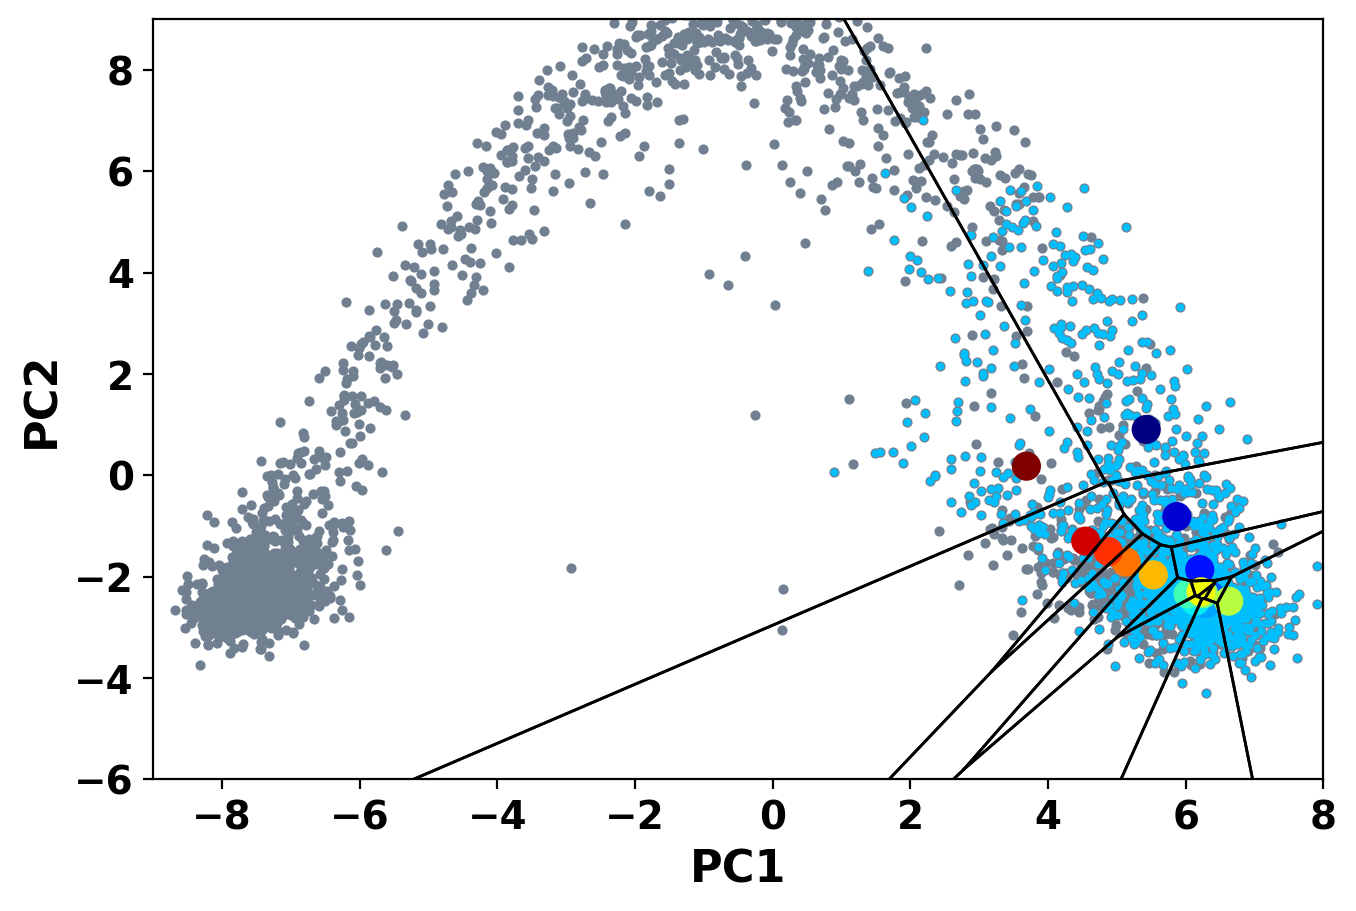

In [12]:
path_r=path.copy()
path_r[:,0]=-path[:,0]
fig,ax=plt.subplots(figsize=(7.5,5))
plt.scatter(-adata.obsm['X_pca'][:,0],adata.obsm['X_pca'][:,1],color='slategrey',s=10,alpha=1)


colors =plt.cm.viridis(np.linspace(0, 1, len(path_neigh)))
for i in range(len(path_neigh)):
    plt.scatter(-adata.obsm['X_pca'][path_neigh[i],0],adata.obsm['X_pca'][path_neigh[i],1],color='deepskyblue',s=5)#color=colors[i]

vor = Voronoi(path_r[:,:2])
regions, vertices = voronoi_finite_polygons_2d(vor,radius=200)
for region in regions:
    polygon = vertices[region]
    for i in range(0,len(polygon)-1):
        plt.plot([polygon[i,0],polygon[i+1,0]], [polygon[i,1],polygon[i+1,1]], linewidth=1,color='k')
    plt.plot([polygon[-1,0],polygon[0,0]], [polygon[-1,1],polygon[0,1]], linewidth=1,color='k')
    
dot_color=np.arange(path.shape[0])
cm=plt.cm.get_cmap('jet')

plt.scatter(-path[:,0],path[:,1],s=100,c=dot_color,cmap=cm)

plt.xticks(fontsize=14,fontweight='bold')
plt.yticks(fontsize=14,fontweight='bold') 

plt.ylabel('PC2',fontsize=16,fontweight='bold')
plt.xlabel('PC1',fontsize=16,fontweight='bold')
plt.axis([-9,8,-6,9])
plt.savefig(result_path+'EG_rc_tube.png',dpi=300)
plt.show()

In [14]:
# plt.scatter(adata.obsm['X_pca'][:,0],adata.obsm['X_pca'][:,1],c=adata.obs['palantir_pseudotime'].values,cmap=plt.cm.jet,s=5,alpha=0.5)
# plt.show()

In [15]:
sel=[j for nei in path_neigh[1:-1] for j in nei]
X0_ori_sel=X0_ori[np.unique(np.asarray(sel).flatten()),:]
X0_sel=StandardScaler().fit_transform(X0_ori_sel)
V0_ori_sel=V0_ori[np.unique(np.asarray(sel).flatten()),:]
V0_sel=StandardScaler().fit_transform(V0_ori_sel)

In [16]:
X0_bin[np.where(X0_bin==0)]=-1
X0_bin.shape

(3696, 737)

In [17]:
def net_frustration(X,V,F):
    frus_score=[]
    V_sign=np.sign(V)
#     F_sign=np.sign(F)
    for i in range(V.shape[0]):
        F_sign=np.sign((X[i,:]>0).astype(np.int16)*((F*X[i,:]).T))
        edge_frus=F_sign#V_sign[i,:]*F_sign
        frus_ratio=(np.count_nonzero(F_sign)-np.sum(edge_frus))*0.5/np.count_nonzero(F)
        frus_score.append(frus_ratio)
    return np.array(frus_score)

In [18]:
def net_H(X,V,F):
    pseudo_h=[]
    V_sign=np.sign(V)
#     F_sign=np.sign(F)
    for i in range(V.shape[0]):
        F_sign=np.sign((X[i,:]>0).astype(np.int16)*((F*X[i,:]).T))

        pseudo_h.append(-np.sum(F_sign))
    return np.array(pseudo_h)

In [19]:
"PLSR for infering GRN"

'PLSR for infering GRN'

In [20]:
n=V0.shape[1]
print(n,X0_sel.shape)
F=np.zeros((n,n))
for i in range(n):
#     print(i)
    pls2 = PLSRegression(n_components=2)
    x=np.delete(X0_sel, i, 1)
    pls2.fit(x, V0_sel[:,i])
    fi=pls2.coef_
    if i==0:
        F[1:,i]=fi[:,0]
    elif i==n-1:
        F[:n-1,i]=fi[:,0]
    else:
        F[:i,i]=fi[:i,0]
        F[i+1:,i]=fi[i:,0]

F=F/np.amax(F)

737 (1128, 737)


/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/sklearn/cross_decomposition/_pls.py:507: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(
/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/sklearn/cross_decomposition/_pls.py:507: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(
/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/sklearn/cross_decomposition/_pls.py:507: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-lea

In [21]:
"save the F matrix with sparse format"

'save the F matrix with sparse format'

In [22]:
Xf_mask=(VarianceThreshold().fit(X0)).variances_>=0
Vf_mask=(VarianceThreshold().fit(V0)).variances_>=0

    
row_inds=np.array([i*np.ones(np.where(Vf_mask)[0].shape) for i in np.where(Xf_mask)[0]]).flatten()
col_inds=np.array([np.where(Vf_mask)[0] for i in np.where(Xf_mask)[0]]).flatten()

inds=np.concatenate((row_inds[:,None],col_inds[:,None]),axis=1)
F_sparse=np.concatenate((inds,F.flatten()[:,None]),axis=1)
np.save(result_path+'dyn_EG_F.npy',F_sparse)

In [23]:
"got the 6th step locfdr for obtaing sparse F matrix"

'got the 6th step locfdr for obtaing sparse F matrix'

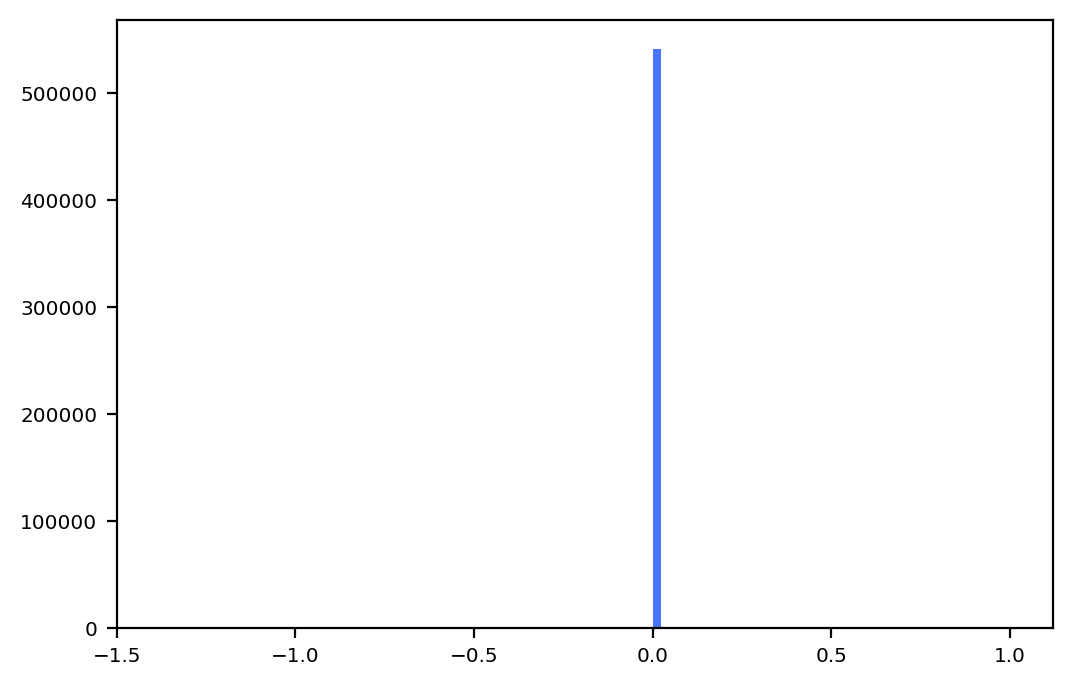

(1817,)


In [28]:
F_sparse=np.load(result_path+'sparse_EG_F.npy')
plt.hist(F_sparse[:,2],bins=100)
plt.show()
F=csr_matrix((F_sparse[:,2], (F_sparse[:,0], F_sparse[:,1])), shape=(V0.shape[1],V0.shape[1])).toarray()
print(np.where(F_sparse[:,2]!=0)[0].shape)

In [9]:
"calculate Frustration score along the reaction coordinate"

'calculate Frustration score along the reaction coordinate'

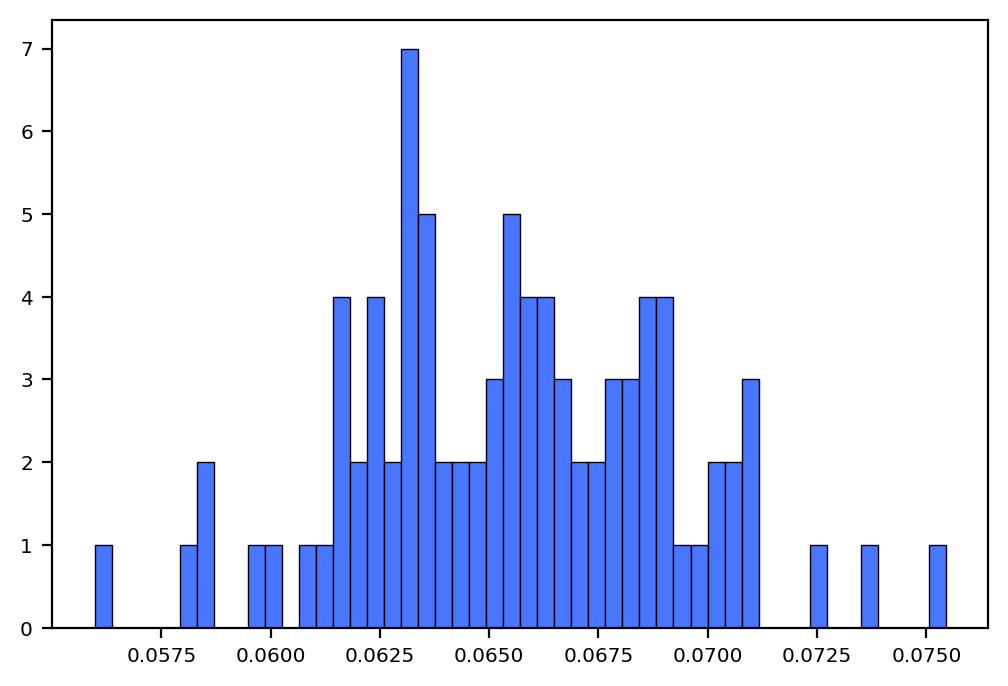

0.06551241811067256


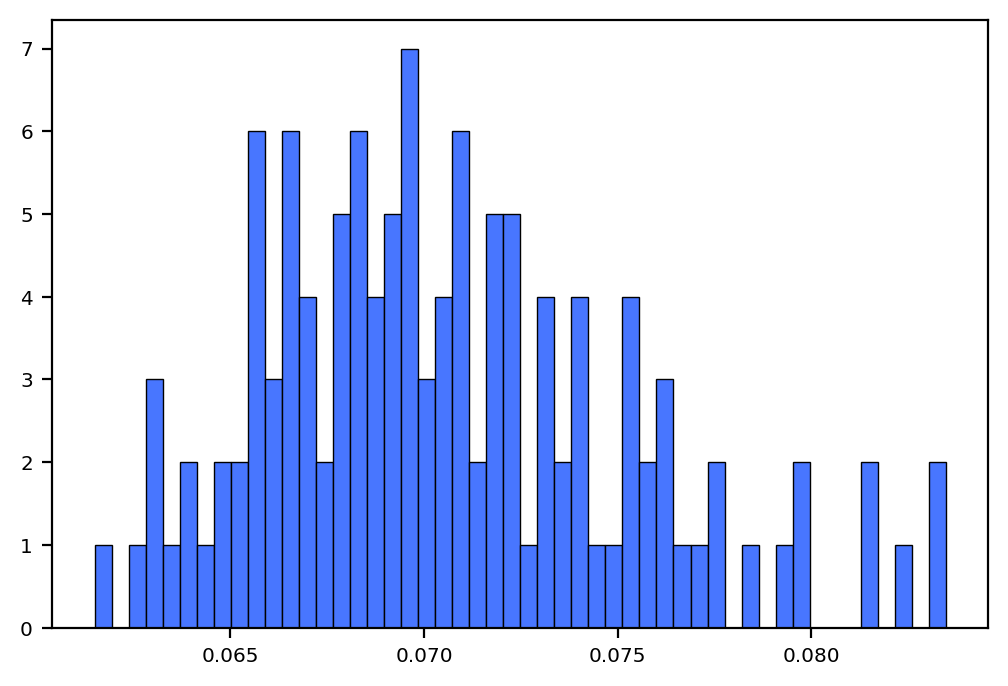

0.07056287750457711


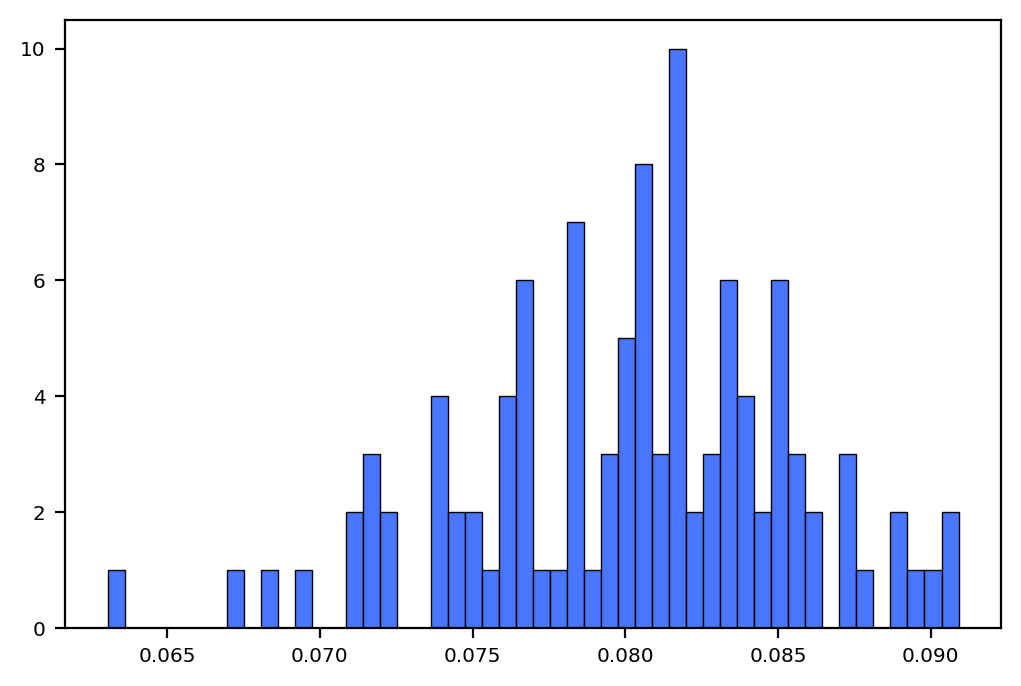

0.08016427009649857


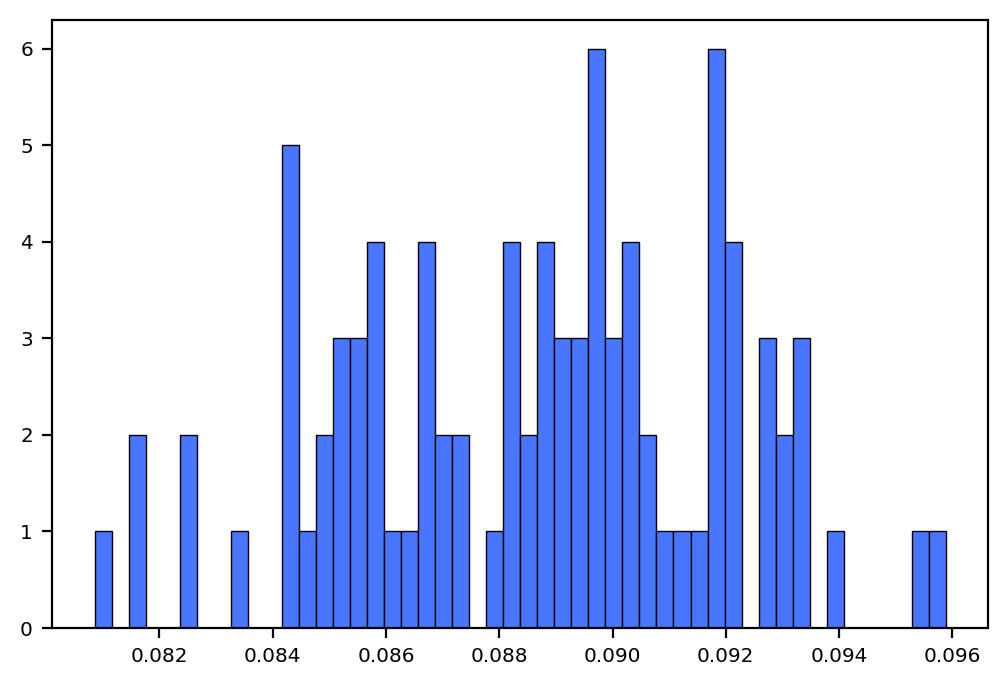

0.08860831772322457


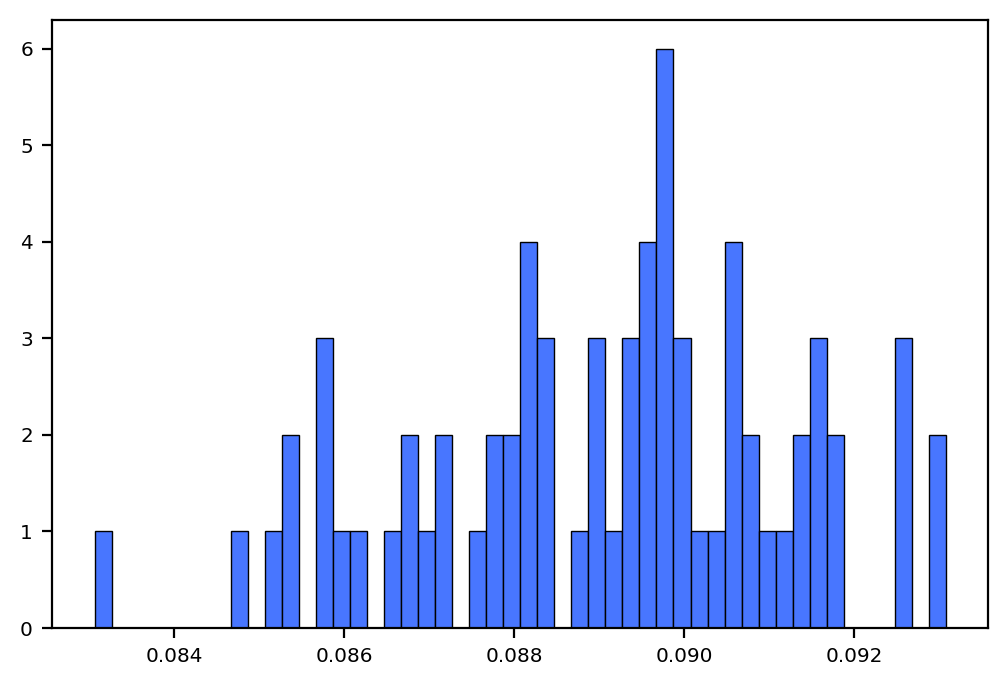

0.08904948844203942


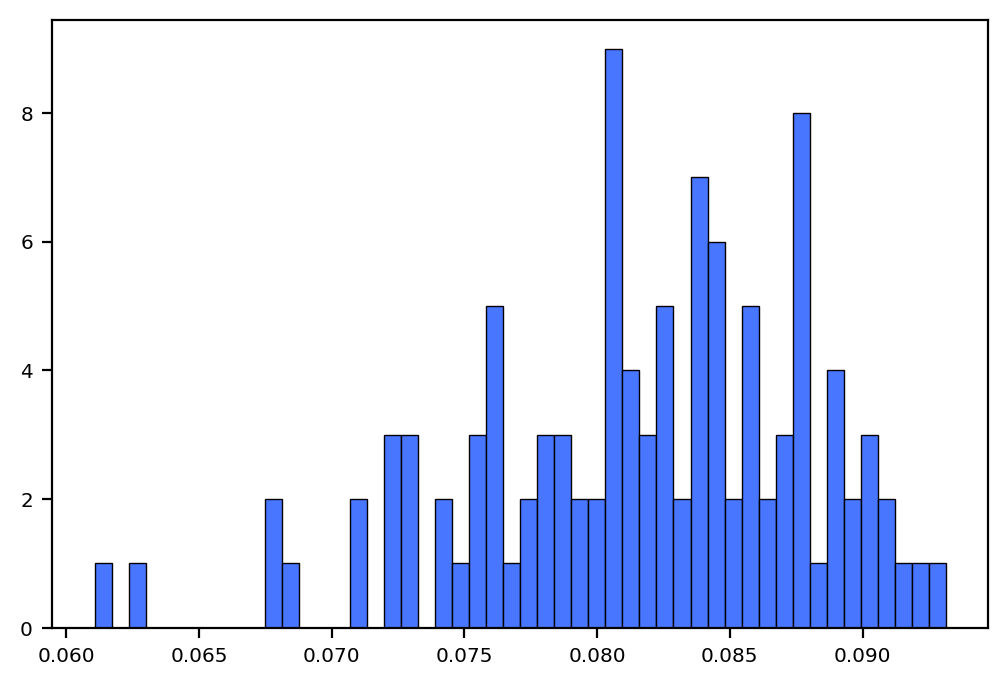

0.08161233595692707


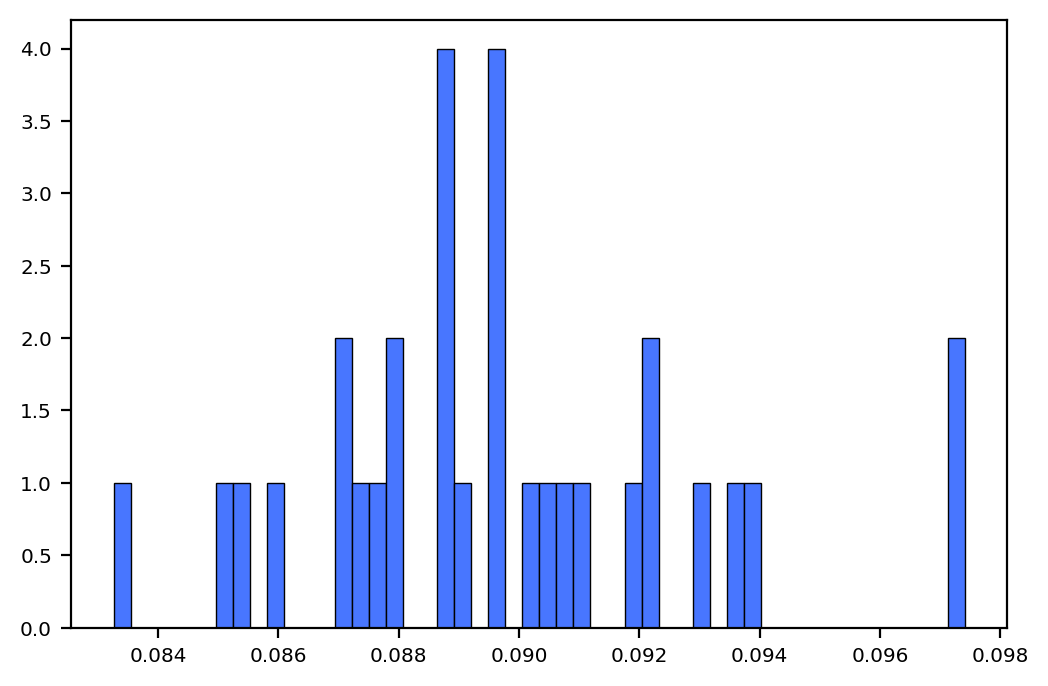

0.08973205341042449


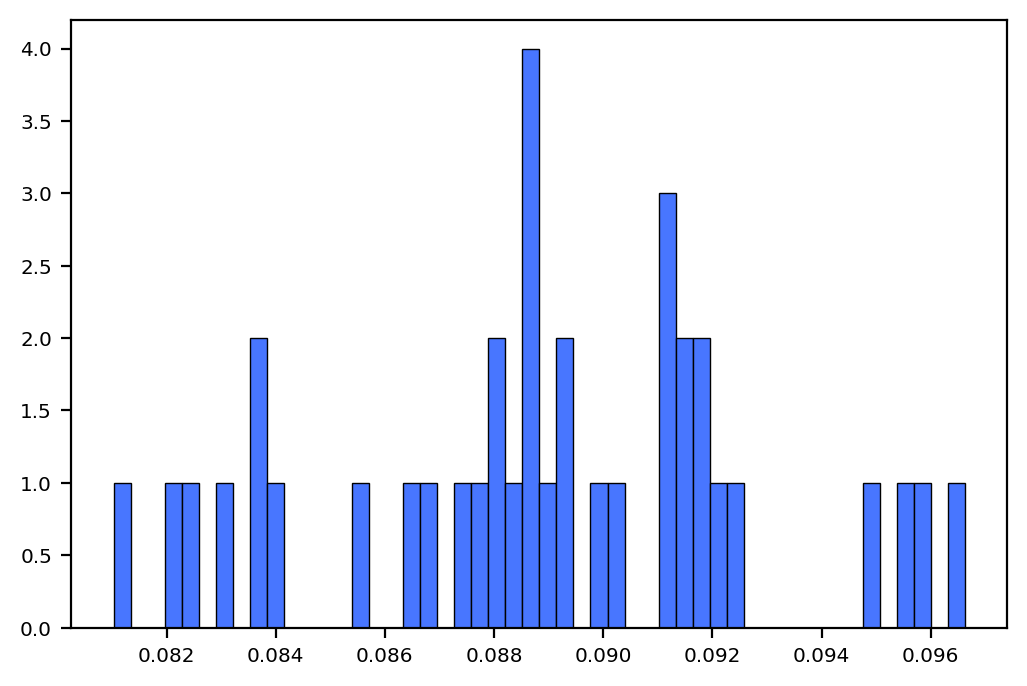

0.08887668169500469


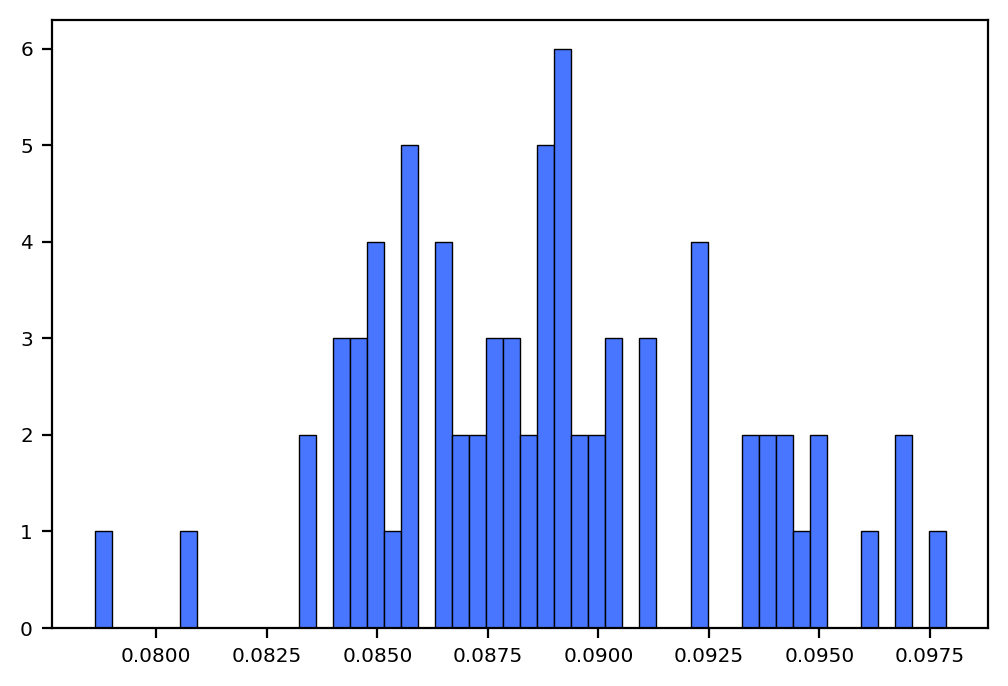

0.08881010835591581


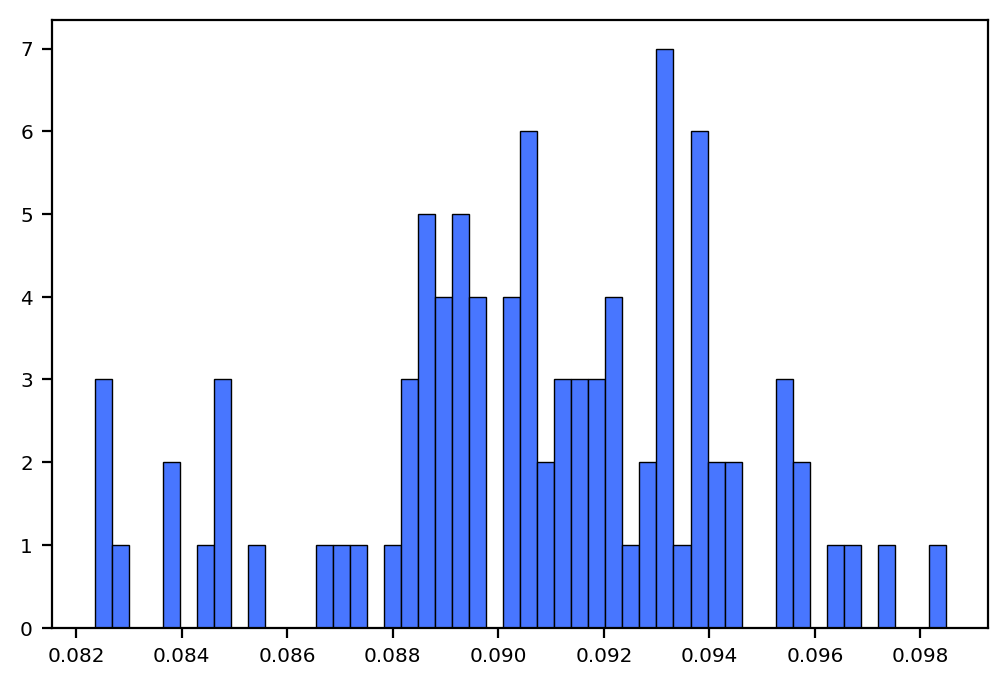

0.09065355119592032


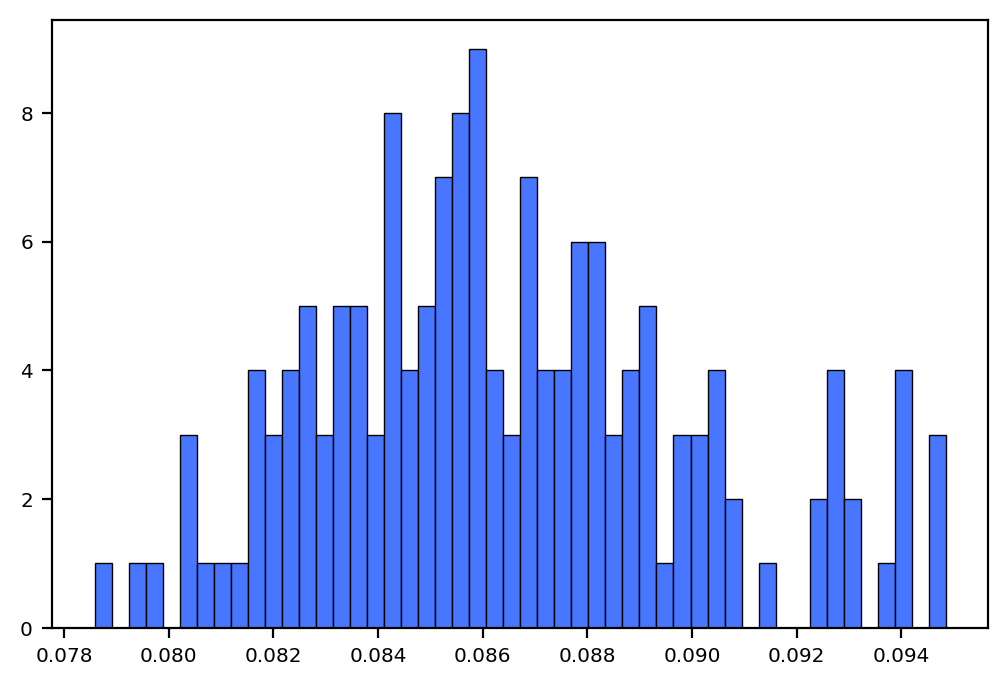

0.0864537002197687


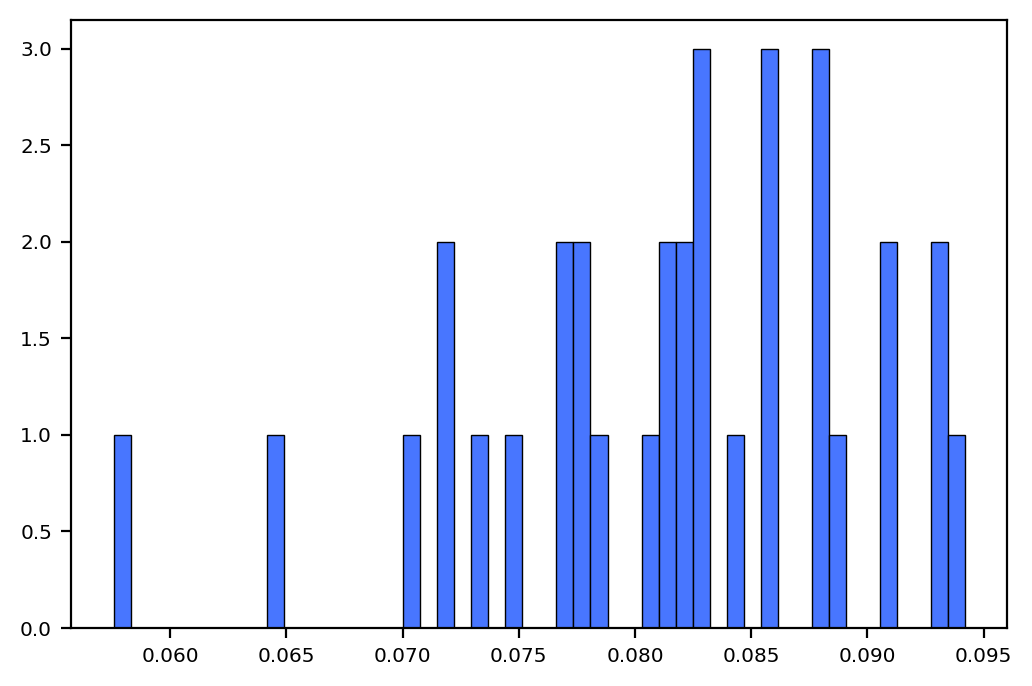

0.08134864617783874


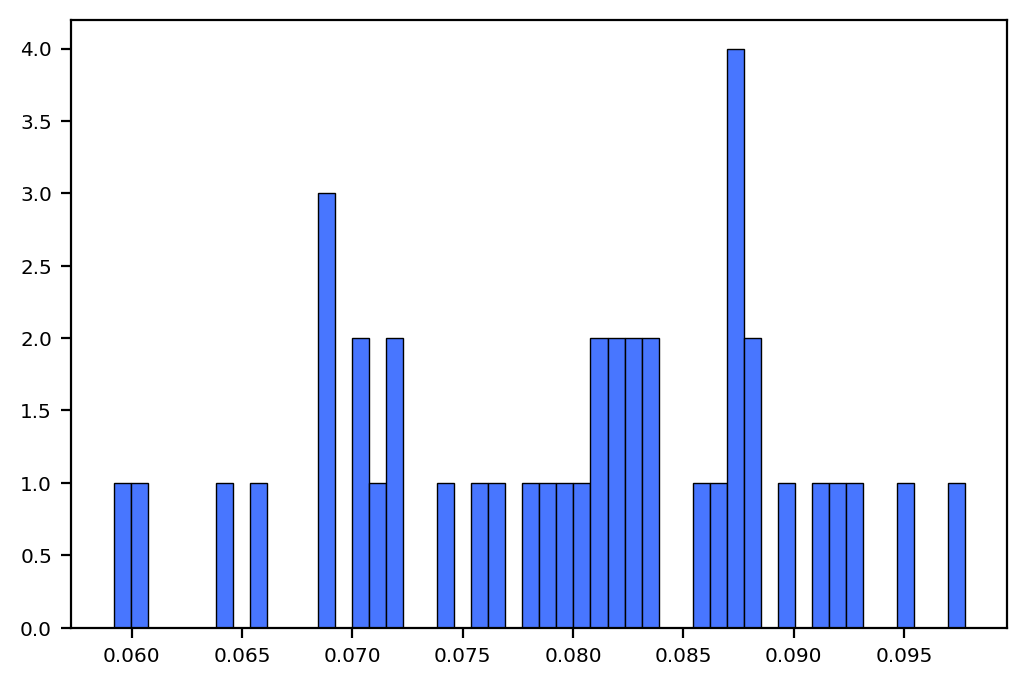

0.07971280505839665


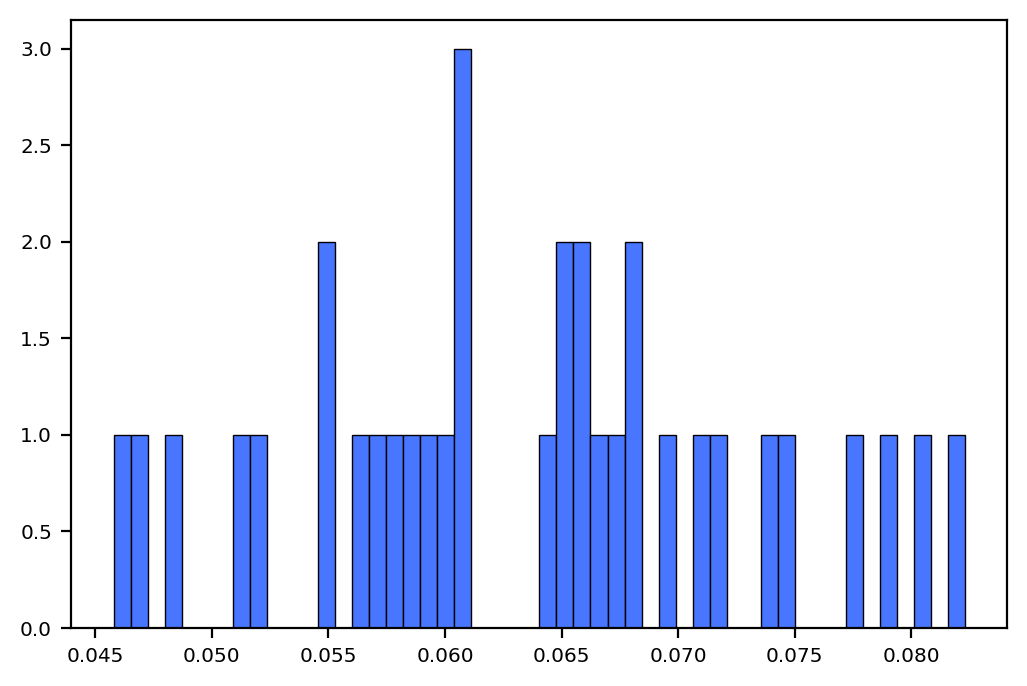

0.06360125571967917


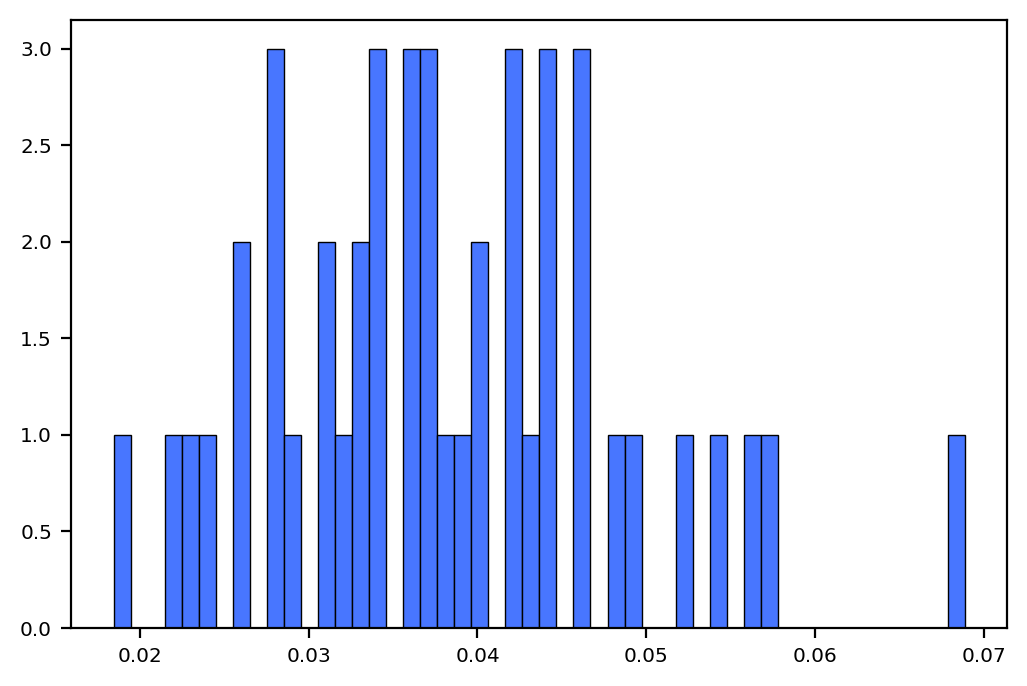

0.038195101712182454


In [26]:
frus_scores=[]
path_frus=[]

pseudo_H=[]
path_H=[]

for i in range(1,rc_extend.shape[0]-1):

        
    

    X=X0[path_neigh[i]]
    V=V0[path_neigh[i]]
#     print(path_neigh[i])
    
    X_ori=X0_ori[path_neigh[i]]
    V_ori=V0_ori[path_neigh[i]]
    X_bin=X0_bin[path_neigh[i]]

    group_frus_score=net_frustration(X_bin,V_ori,F)
    plt.hist(group_frus_score,bins=50,edgecolor='k')
    plt.show()
    frus_scores.append(group_frus_score)
    
    path_frus.append(np.mean(group_frus_score))
    print(np.mean(group_frus_score))
    group_H=net_H(X_bin,V_ori,F)
    pseudo_H.append(group_H)
    path_H.append(np.mean(group_H))

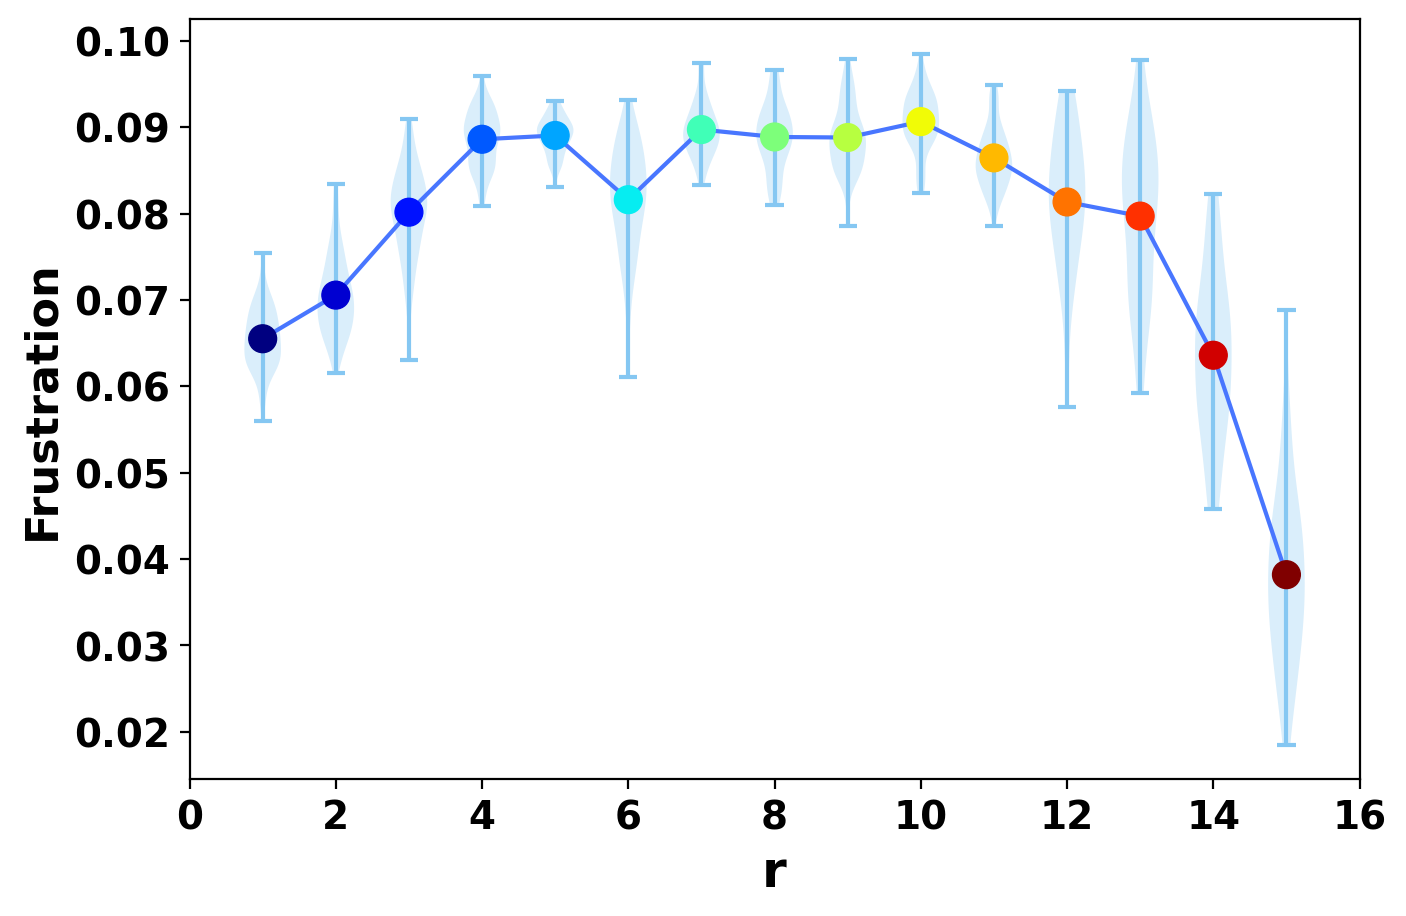

In [27]:


fig,ax=plt.subplots(figsize=(7.5,5))
dot_color=np.arange(path.shape[0])
cm=plt.cm.get_cmap('jet')
plt.plot(np.arange(path.shape[0])+1,path_frus)

plt.violinplot(frus_scores,positions=np.arange(path.shape[0])+1)
plt.scatter(np.arange(path.shape[0])+1,path_frus,s=100,c=dot_color,cmap=cm,zorder=10)
plt.ylabel('Frustration',fontsize=16,fontweight='bold')
plt.xlabel('r',fontsize=18,fontweight='bold')

plt.xticks(np.arange(17,step=2),fontsize=14,fontweight='bold')
plt.yticks(fontsize=14,fontweight='bold')  
# plt.axis([0,16,0,0.4])
plt.savefig(result_path+'EG_frus.png',dpi=300)
plt.show()